# EDA 9.3: Reorder Supply Planning Analysis

This notebook analyzes reorder behavior, fill rate, days of supply, and their observed relationship with current and next-month Revenue. Inventory appears monthly in this dataset, so supply signals are aggregated at month level first and then lagged before any forecasting preview.

## 1. Setup and File Discovery

Locate `inventory.csv`, `products.csv`, `sales.csv`, and optional order files anywhere under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 220)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['inventory.csv', 'products.csv', 'sales.csv', 'orders.csv', 'order_items.csv']

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in ['inventory.csv', 'products.csv', 'sales.csv'], 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in ['inventory.csv', 'products.csv', 'sales.csv']:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,inventory.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\in...
1,products.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
2,sales.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
3,orders.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,order_items.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...


## 2. Load Inventory, Products, Sales, and Optional Files

Load all available CSVs safely with pandas and display the raw schemas.

In [2]:
def safe_read_csv(path, name):
    if path is None:
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns from {path}')
        return df
    except Exception as exc:
        warnings.warn(f'Could not load {name} from {path}: {exc}')
        return None

raw = {name: safe_read_csv(path, name) for name, path in selected_paths.items()}
inventory_raw = raw.get('inventory.csv')
products_raw = raw.get('products.csv')
sales_raw = raw.get('sales.csv')
orders_raw = raw.get('orders.csv')
order_items_raw = raw.get('order_items.csv')

schema_rows = []
for name, df in raw.items():
    if df is not None:
        schema_rows.append({'file': name, 'rows': len(df), 'columns': len(df.columns), 'column_names': ', '.join(map(str, df.columns))})
schema_overview = pd.DataFrame(schema_rows)
display(schema_overview)

Loaded inventory.csv: 60,247 rows x 17 columns from D:\Code\Datathon 2026\datathon-2026-round-1\inventory.csv
Loaded products.csv: 2,412 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\products.csv
Loaded sales.csv: 3,833 rows x 3 columns from D:\Code\Datathon 2026\datathon-2026-round-1\sales.csv


Loaded orders.csv: 646,945 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\orders.csv


Loaded order_items.csv: 714,669 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\order_items.csv


,file,rows,columns,column_names
0,inventory.csv,60247,17,"snapshot_date, product_id, stock_on_hand, unit..."
1,products.csv,2412,8,"product_id, product_name, category, segment, s..."
2,sales.csv,3833,3,"Date, Revenue, COGS"
3,orders.csv,646945,8,"order_id, order_date, customer_id, zip, order_..."
4,order_items.csv,714669,7,"order_id, product_id, quantity, unit_price, di..."


## 3. Identify Product, Inventory, Reorder, Fill-Rate, Days-of-Supply, Category, Segment, and Revenue Columns

Column matching normalizes case, spaces, punctuation, and underscores, then uses candidate names and keyword scoring for minor naming differences.

In [3]:
def column_lookup(df):
    if df is None:
        return {}
    return {normalize_name(c): c for c in df.columns}

def find_col(df, candidates=None, include_all=None, include_any=None, exclude_any=None, prefer_numeric=False):
    if df is None:
        return None
    candidates = candidates or []
    include_all = [normalize_name(x) for x in (include_all or [])]
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup:
            return lookup[key]
    scored = []
    for col in df.columns:
        key = normalize_name(col)
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_all and not all(x in key for x in include_all):
            continue
        if include_any and not any(x in key for x in include_any):
            continue
        score = sum(3 for x in include_all if x in key) + sum(2 for x in include_any if x in key)
        if prefer_numeric and pd.api.types.is_numeric_dtype(df[col]):
            score += 1
        scored.append((score, len(key), col))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1], str(x[2])))
        return scored[0][2]
    return None

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

def infer_revenue_col(df):
    if df is None:
        return None
    direct = find_col(
        df,
        ['revenue', 'total_revenue', 'sales_amount', 'sales', 'net_sales', 'amount'],
        include_any=['revenue', 'salesamount', 'totalsales', 'netsales'],
        exclude_any=['cost', 'cogs', 'margin', 'profit', 'tax'],
        prefer_numeric=True,
    )
    if direct is not None:
        return direct
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) or to_num(df[c]).notna().mean() > 0.8]
    candidates = []
    for c in numeric_cols:
        key = normalize_name(c)
        if any(x in key for x in ['cost', 'cogs', 'margin', 'profit', 'tax', 'id']):
            continue
        vals = to_num(df[c])
        candidates.append(((vals > 0).mean(), vals.abs().sum(skipna=True), c))
    if candidates:
        candidates.sort(key=lambda x: (-x[0], -x[1], str(x[2])))
        warnings.warn(f'Revenue column was not explicit; using likely numeric revenue column: {candidates[0][2]}')
        return candidates[0][2]
    return None

cols = {}
if inventory_raw is not None:
    cols['inv_product_id'] = find_col(inventory_raw, ['product_id', 'productid', 'sku_id', 'item_id'], include_any=['productid', 'skuid', 'itemid'])
    cols['inv_date'] = find_col(inventory_raw, ['snapshot_date', 'inventory_date', 'date', 'month_end_date'], include_any=['snapshotdate', 'inventorydate', 'date'])
    cols['inv_year'] = find_col(inventory_raw, ['year'], include_any=['year'], prefer_numeric=True)
    cols['inv_month'] = find_col(inventory_raw, ['month'], include_any=['month'], prefer_numeric=True)
    cols['reorder_flag'] = find_col(inventory_raw, ['reorder_flag', 'reorder', 'needs_reorder', 'purchase_order_flag', 'replenishment_flag'], include_any=['reorderflag', 'reorder', 'needsreorder', 'purchaseorderflag', 'replenishmentflag'], prefer_numeric=True)
    cols['reorder_qty'] = find_col(inventory_raw, ['reorder_qty', 'reorder_quantity', 'purchase_qty', 'replenishment_qty'], include_any=['reorderqty', 'reorderquantity', 'purchaseqty', 'replenishmentqty'], prefer_numeric=True)
    cols['stock_on_hand'] = find_col(inventory_raw, ['stock_on_hand', 'stock_qty', 'inventory_qty', 'available_quantity', 'available_inventory', 'on_hand_qty'], include_any=['stockonhand', 'stockqty', 'inventoryqty', 'availablequantity', 'availableinventory', 'onhandqty'], prefer_numeric=True)
    cols['fill_rate'] = find_col(inventory_raw, ['fill_rate', 'availability_rate', 'service_level'], include_any=['fillrate', 'availabilityrate', 'servicelevel'], prefer_numeric=True)
    cols['days_of_supply'] = find_col(inventory_raw, ['days_of_supply', 'inventory_days_of_supply'], include_any=['daysofsupply'], prefer_numeric=True)
    cols['inv_units_sold'] = find_col(inventory_raw, ['units_sold', 'quantity_sold', 'qty_sold', 'sales_units'], include_any=['unitssold', 'quantitysold', 'qtysold', 'salesunits'], prefer_numeric=True)
    cols['inv_category'] = find_col(inventory_raw, ['category', 'product_category'], include_any=['category'])
    cols['inv_segment'] = find_col(inventory_raw, ['segment', 'product_segment'], include_any=['segment'])
if products_raw is not None:
    cols['prod_product_id'] = find_col(products_raw, ['product_id', 'productid', 'sku_id', 'item_id'], include_any=['productid', 'skuid', 'itemid'])
    cols['prod_category'] = find_col(products_raw, ['category', 'product_category'], include_any=['category'])
    cols['prod_segment'] = find_col(products_raw, ['segment', 'product_segment'], include_any=['segment'])
if sales_raw is not None:
    cols['sales_date'] = find_col(sales_raw, ['date', 'sales_date', 'order_date'], include_any=['date'])
    cols['sales_revenue'] = infer_revenue_col(sales_raw)
if order_items_raw is not None:
    cols['oi_order_id'] = find_col(order_items_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['oi_product_id'] = find_col(order_items_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['oi_quantity'] = find_col(order_items_raw, ['quantity', 'qty', 'units_sold'], include_any=['quantity', 'qty', 'unitssold'], prefer_numeric=True)
if orders_raw is not None:
    cols['orders_order_id'] = find_col(orders_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['orders_date'] = find_col(orders_raw, ['order_date', 'date'], include_any=['orderdate', 'date'])

identified_columns = pd.DataFrame([{'role': k, 'column': v} for k, v in cols.items()])
display(identified_columns)

,role,column
0,inv_product_id,product_id
1,inv_date,snapshot_date
2,inv_year,year
3,inv_month,month
4,reorder_flag,reorder_flag
5,reorder_qty,None
6,stock_on_hand,stock_on_hand
7,fill_rate,fill_rate
8,days_of_supply,days_of_supply
9,inv_units_sold,units_sold


## 4. Inventory and Reorder Data Quality Checks

Inspect inventory date coverage, granularity, duplicate product-period rows, and missing reorder, fill-rate, and stock fields.

In [4]:
inventory = pd.DataFrame()
inventory_warnings = []
inventory_granularity = 'unknown'

if inventory_raw is None or inventory_raw.empty:
    inventory_warnings.append('inventory.csv is missing or empty.')
elif cols.get('inv_product_id') is None:
    inventory_warnings.append('Inventory product ID column could not be identified.')
else:
    inventory = inventory_raw.copy()
    inventory['product_id_std'] = inventory[cols['inv_product_id']].astype('string').str.strip()
    if cols.get('inv_date'):
        inventory['inventory_date'] = pd.to_datetime(inventory[cols['inv_date']], errors='coerce').dt.floor('D')
    elif cols.get('inv_year') and cols.get('inv_month'):
        inventory['inventory_date'] = pd.to_datetime(
            inventory[cols['inv_year']].astype('Int64').astype(str) + '-' + inventory[cols['inv_month']].astype('Int64').astype(str).str.zfill(2) + '-01',
            errors='coerce'
        ) + pd.offsets.MonthEnd(0)
    else:
        inventory['inventory_date'] = pd.NaT
        inventory_warnings.append('Inventory date/month could not be identified.')

    if cols.get('stock_on_hand'):
        inventory['stock_on_hand_std'] = to_num(inventory[cols['stock_on_hand']])
    if cols.get('reorder_flag'):
        inventory['reorder_flag_raw'] = to_num(inventory[cols['reorder_flag']])
    if cols.get('reorder_qty'):
        inventory['reorder_qty_raw'] = to_num(inventory[cols['reorder_qty']])
    if cols.get('fill_rate'):
        fr = to_num(inventory[cols['fill_rate']])
        inventory['fill_rate_std'] = np.where(fr.abs() > 1.5, fr / 100.0, fr)
    if cols.get('days_of_supply'):
        inventory['days_of_supply_std'] = to_num(inventory[cols['days_of_supply']])
    if cols.get('inv_units_sold'):
        inventory['inventory_units_sold_std'] = to_num(inventory[cols['inv_units_sold']])

    if inventory['inventory_date'].notna().sum() >= 2:
        diffs = inventory[['inventory_date']].dropna().sort_values('inventory_date')['inventory_date'].diff().dropna().dt.days
        if not diffs.empty:
            med = diffs.median()
            inventory_granularity = 'monthly' if med >= 25 else ('daily' if med <= 2 else 'irregular')
        else:
            inventory_granularity = 'single_period'

    duplicate_rows = int(inventory.duplicated(['product_id_std', 'inventory_date']).sum()) if 'inventory_date' in inventory else np.nan
    report = pd.DataFrame([
        {'metric': 'inventory_date_range_start', 'value': inventory['inventory_date'].min()},
        {'metric': 'inventory_date_range_end', 'value': inventory['inventory_date'].max()},
        {'metric': 'inventory_rows', 'value': len(inventory)},
        {'metric': 'unique_products', 'value': inventory['product_id_std'].nunique(dropna=True)},
        {'metric': 'missing_product_ids', 'value': int(inventory['product_id_std'].isna().sum())},
        {'metric': 'missing_inventory_dates', 'value': int(inventory['inventory_date'].isna().sum())},
        {'metric': 'missing_reorder_fields', 'value': int(inventory['reorder_flag_raw'].isna().sum()) if 'reorder_flag_raw' in inventory else np.nan},
        {'metric': 'missing_fill_rate', 'value': int(inventory['fill_rate_std'].isna().sum()) if 'fill_rate_std' in inventory else np.nan},
        {'metric': 'missing_stock_fields', 'value': int(inventory['stock_on_hand_std'].isna().sum()) if 'stock_on_hand_std' in inventory else np.nan},
        {'metric': 'duplicate_product_period_rows', 'value': duplicate_rows},
        {'metric': 'detected_granularity', 'value': inventory_granularity},
    ])
    display(report)
    display(inventory.head())
    numeric_cols = [c for c in ['stock_on_hand_std', 'reorder_flag_raw', 'reorder_qty_raw', 'fill_rate_std', 'days_of_supply_std', 'inventory_units_sold_std'] if c in inventory.columns]
    if numeric_cols:
        display(inventory[numeric_cols].describe().T)

if inventory_warnings:
    print('Inventory warnings:')
    for w in inventory_warnings:
        print('-', w)

,metric,value
0,inventory_date_range_start,2012-07-31 00:00:00
1,inventory_date_range_end,2022-12-31 00:00:00
2,inventory_rows,60247
3,unique_products,1624
4,missing_product_ids,0
5,missing_inventory_dates,0
6,missing_reorder_fields,0
7,missing_fill_rate,0
8,missing_stock_fields,0
9,duplicate_product_period_rows,0


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month,product_id_std,inventory_date,stock_on_hand_std,reorder_flag_raw,fill_rate_std,days_of_supply_std,inventory_units_sold_std
0,2022-10-31,1,3,1,1,2,90.0000,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10,1,2022-10-31,3,0,0.9333,90.0000,1
1,2022-11-30,1,3,1,1,1,90.0000,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11,1,2022-11-30,3,0,0.9667,90.0000,1
2,2022-12-31,1,3,1,1,1,90.0000,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12,1,2022-12-31,3,0,0.9667,90.0000,1
3,2016-04-30,3,35,13,11,2,95.5000,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4,3,2016-04-30,35,0,0.9333,95.5000,11
4,2016-05-31,3,36,11,10,1,108.0000,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5,3,2016-05-31,36,0,0.9667,108.0000,10


,count,mean,std,min,25%,50%,75%,max
stock_on_hand_std,"60,247.0000",189.2985,316.9761,3.0000,15.0000,62.0000,210.0000,"2,673.0000"
reorder_flag_raw,"60,247.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
fill_rate_std,"60,247.0000",0.9613,0.0542,0.0667,0.9333,0.9667,1.0000,1.0000
days_of_supply_std,"60,247.0000",912.6776,"2,587.6241",5.2000,96.0000,240.0000,683.1000,"68,100.0000"
inventory_units_sold_std,"60,247.0000",15.4178,28.4044,1.0000,2.0000,6.0000,16.0000,670.0000


## 5. Join Inventory with Products

Join inventory to products by product ID, bring in category and segment when available, and report join quality.

In [5]:
inventory_joined = pd.DataFrame()
join_quality = pd.DataFrame()

if inventory.empty:
    print('Inventory data is unavailable; product join cannot be computed.')
else:
    inventory_joined = inventory.copy()
    if products_raw is not None and cols.get('prod_product_id'):
        prod = products_raw.copy()
        prod['product_id_std'] = prod[cols['prod_product_id']].astype('string').str.strip()
        prod_keep = ['product_id_std']
        for c in [cols.get('prod_category'), cols.get('prod_segment')]:
            if c and c not in prod_keep:
                prod_keep.append(c)
        prod = prod[prod_keep].drop_duplicates('product_id_std')
        product_id_set = set(prod['product_id_std'].dropna())
        matched = int(inventory_joined['product_id_std'].isin(product_id_set).sum())
        unmatched = int(len(inventory_joined) - matched)
        products_without_inventory = int(len(prod.loc[~prod['product_id_std'].isin(set(inventory_joined['product_id_std'].dropna()))]))
        inventory_joined = inventory_joined.merge(prod, on='product_id_std', how='left', suffixes=('', '_prod'))
        join_quality = pd.DataFrame([
            {'metric': 'inventory_rows_matched_to_products', 'value': matched},
            {'metric': 'inventory_rows_unmatched_to_products', 'value': unmatched},
            {'metric': 'products_without_inventory_records', 'value': products_without_inventory},
        ])
        display(join_quality)
        if unmatched > 0:
            print('Sample unmatched product IDs:')
            display(inventory_joined.loc[~inventory_joined['product_id_std'].isin(product_id_set), ['product_id_std']].drop_duplicates().head(20))
    else:
        print('Products file or product key is unavailable; join quality cannot be fully evaluated.')
        inventory_joined = inventory.copy()

    inv_cat_col = cols.get('inv_category') if cols.get('inv_category') in inventory_joined.columns else None
    prod_cat_col = cols.get('prod_category') if cols.get('prod_category') in inventory_joined.columns else None
    inv_seg_col = cols.get('inv_segment') if cols.get('inv_segment') in inventory_joined.columns else None
    prod_seg_col = cols.get('prod_segment') if cols.get('prod_segment') in inventory_joined.columns else None
    if inv_cat_col:
        inventory_joined['category_final'] = inventory_joined[inv_cat_col].astype('string').fillna('Unknown')
    elif prod_cat_col:
        inventory_joined['category_final'] = inventory_joined[prod_cat_col].astype('string').fillna('Unknown')
    else:
        inventory_joined['category_final'] = 'Unknown'
        inventory_warnings.append('Product category could not be identified; category-level analysis will be limited.')
    if inv_seg_col:
        inventory_joined['segment_final'] = inventory_joined[inv_seg_col].astype('string').fillna('Unknown')
    elif prod_seg_col:
        inventory_joined['segment_final'] = inventory_joined[prod_seg_col].astype('string').fillna('Unknown')
    else:
        inventory_joined['segment_final'] = pd.NA
        inventory_warnings.append('Product segment could not be identified; segment-level analysis may be limited.')

,metric,value
0,inventory_rows_matched_to_products,60247
1,inventory_rows_unmatched_to_products,0
2,products_without_inventory_records,788


## 6. Define Reorder and Supply Metrics

Create reorder flags, fill rate, stock on hand, and days of supply. If days of supply is unavailable, estimate it from stock on hand and historical units sold using monthly demand.

In [6]:
supply_definition = ''
monthly_supply = pd.DataFrame()
sales_qty_warnings = []

def build_monthly_units_from_orders(order_items_df, orders_df):
    if order_items_df is None or orders_df is None:
        return pd.DataFrame()
    if not (cols.get('oi_product_id') and cols.get('oi_quantity') and cols.get('oi_order_id') and cols.get('orders_order_id') and cols.get('orders_date')):
        return pd.DataFrame()
    oi = order_items_df.copy()
    oi['product_id_std'] = oi[cols['oi_product_id']].astype('string').str.strip()
    oi['units_sold'] = to_num(oi[cols['oi_quantity']])
    od = orders_df[[cols['orders_order_id'], cols['orders_date']]].drop_duplicates(cols['orders_order_id']).copy()
    od['order_date_std'] = pd.to_datetime(od[cols['orders_date']], errors='coerce').dt.floor('D')
    oi = oi.merge(od[[cols['orders_order_id'], 'order_date_std']], left_on=cols['oi_order_id'], right_on=cols['orders_order_id'], how='left')
    oi = oi.dropna(subset=['order_date_std'])
    oi['year_month'] = oi['order_date_std'].dt.to_period('M').astype('string')
    return oi.groupby(['product_id_std', 'year_month'], as_index=False)['units_sold'].sum(min_count=1)

if inventory_joined.empty:
    print('Inventory data is unavailable; reorder and supply metrics cannot be defined.')
else:
    inv = inventory_joined.copy()
    inv['year_month'] = inv['inventory_date'].dt.to_period('M').astype('string')
    if 'reorder_flag_raw' in inv.columns and inv['reorder_flag_raw'].notna().any():
        inv['reorder_flag_final'] = inv['reorder_flag_raw'].fillna(0) > 0
        supply_definition = 'Used existing reorder_flag field.'
    elif 'reorder_qty_raw' in inv.columns and inv['reorder_qty_raw'].notna().any():
        inv['reorder_flag_final'] = inv['reorder_qty_raw'].fillna(0) > 0
        supply_definition = 'Inferred reorder_flag from reorder_quantity > 0 because explicit reorder_flag was unavailable.'
    else:
        inv['reorder_flag_final'] = pd.NA
        supply_definition = 'Reorder flag could not be identified or inferred.'
        sales_qty_warnings.append('Reorder flag could not be identified or inferred from inventory fields.')

    monthly_rows = []
    for (pid, ym), g in inv.dropna(subset=['year_month']).groupby(['product_id_std', 'year_month']):
        last_row = g.sort_values('inventory_date').iloc[-1]
        monthly_rows.append({
            'product_id_std': pid,
            'year_month': ym,
            'month_start': pd.Period(ym).to_timestamp(),
            'category_final': last_row['category_final'] if 'category_final' in g else 'Unknown',
            'segment_final': last_row['segment_final'] if 'segment_final' in g else pd.NA,
            'stock_on_hand': last_row['stock_on_hand_std'] if 'stock_on_hand_std' in g else np.nan,
            'reorder_flag': bool(g['reorder_flag_final'].fillna(False).any()) if 'reorder_flag_final' in g else pd.NA,
            'reorder_count': int(g['reorder_flag_final'].fillna(False).sum()) if 'reorder_flag_final' in g else np.nan,
            'reorder_quantity': g['reorder_qty_raw'].sum(min_count=1) if 'reorder_qty_raw' in g else np.nan,
            'fill_rate': g['fill_rate_std'].mean() if 'fill_rate_std' in g else np.nan,
            'days_of_supply': g['days_of_supply_std'].mean() if 'days_of_supply_std' in g else np.nan,
            'inventory_units_sold': g['inventory_units_sold_std'].sum(min_count=1) if 'inventory_units_sold_std' in g else np.nan,
        })
    monthly_supply = pd.DataFrame(monthly_rows)

    if monthly_supply['inventory_units_sold'].notna().sum() == 0:
        order_units = build_monthly_units_from_orders(order_items_raw, orders_raw)
        if not order_units.empty:
            monthly_supply = monthly_supply.drop(columns=['inventory_units_sold'], errors='ignore').merge(order_units, on=['product_id_std', 'year_month'], how='left')
            monthly_supply['inventory_units_sold'] = monthly_supply['units_sold']
            monthly_supply = monthly_supply.drop(columns=['units_sold'])
        else:
            sales_qty_warnings.append('Units sold could not be rebuilt from orders/order_items; days-of-supply estimation may remain limited.')

    # Estimate days_of_supply only when not available and units_sold exists.
    if monthly_supply['days_of_supply'].notna().sum() == 0 and monthly_supply['inventory_units_sold'].notna().any():
        days_in_month = pd.PeriodIndex(monthly_supply['year_month'], freq='M').days_in_month
        avg_daily_units = monthly_supply['inventory_units_sold'] / days_in_month
        monthly_supply['days_of_supply'] = np.where(avg_daily_units > 0, monthly_supply['stock_on_hand'] / avg_daily_units, np.nan)
        supply_definition += ' Days of supply was estimated as stock_on_hand / (units_sold / days_in_month) when direct days_of_supply was unavailable.'

    monthly_supply['reorder_rate'] = monthly_supply['reorder_count'] / 1.0
    print('Supply metric definition used:')
    print(supply_definition)
    display(monthly_supply.head(20))

Supply metric definition used:
Used existing reorder_flag field.


,product_id_std,year_month,month_start,category_final,segment_final,stock_on_hand,reorder_flag,reorder_count,reorder_quantity,fill_rate,days_of_supply,inventory_units_sold,reorder_rate
0,1,2022-10,2022-10-01,Casual,All-weather,3,False,0,NaN,0.9333,90.0000,1,0.0000
1,1,2022-11,2022-11-01,Casual,All-weather,3,False,0,NaN,0.9667,90.0000,1,0.0000
2,1,2022-12,2022-12-01,Casual,All-weather,3,False,0,NaN,0.9667,90.0000,1,0.0000
3,10,2012-10,2012-10-01,Casual,All-weather,3,False,0,NaN,1.0000,90.0000,1,0.0000
4,10,2013-01,2013-01-01,Casual,All-weather,3,False,0,NaN,1.0000,45.0000,2,0.0000
5,10,2013-02,2013-02-01,Casual,All-weather,4,False,0,NaN,0.9000,20.0000,6,0.0000
6,10,2013-03,2013-03-01,Casual,All-weather,4,False,0,NaN,0.9667,24.0000,5,0.0000
7,10,2013-04,2013-04-01,Casual,All-weather,4,False,0,NaN,0.9667,40.0000,3,0.0000
8,10,2013-05,2013-05-01,Casual,All-weather,4,False,0,NaN,0.9333,60.0000,2,0.0000
9,10,2013-06,2013-06-01,Casual,All-weather,4,False,0,NaN,0.9333,120.0000,1,0.0000


## 7. Products with Frequent Reorder Signals

Aggregate reorder and supply metrics by product and identify products with the highest reorder frequency.

,product_id_std,total_periods_observed,reorder_count,reorder_rate,average_reorder_quantity,average_fill_rate,average_days_of_supply,category_final,segment_final,few_periods_flag
0,1,3,0,0.0000,NaN,0.9556,90.0000,Casual,All-weather,False
1,10,8,0,0.0000,NaN,0.9542,64.8750,Casual,All-weather,False
2,100,10,0,0.0000,NaN,0.9567,130.7100,Streetwear,Balanced,False
3,1000,124,0,0.0000,NaN,0.9661,"1,826.3032",GenZ,Trendy,False
4,1001,115,0,0.0000,NaN,0.9641,"1,201.7635",GenZ,Trendy,False
5,1002,44,0,0.0000,NaN,0.9629,274.2318,GenZ,Trendy,False
6,1003,15,0,0.0000,NaN,0.9711,361.0000,GenZ,Trendy,False
7,1005,95,0,0.0000,NaN,0.9723,"2,207.7158",GenZ,Trendy,False
8,1006,77,0,0.0000,NaN,0.9571,"1,275.7299",GenZ,Trendy,False
9,1007,84,0,0.0000,NaN,0.9647,137.2190,GenZ,Trendy,False


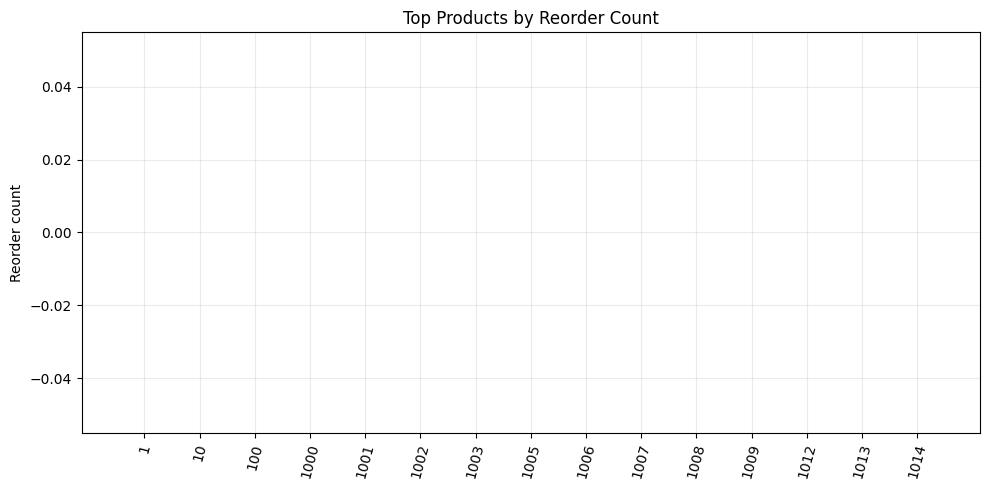

In [7]:
product_reorder = pd.DataFrame()
if monthly_supply.empty:
    print('Monthly supply data is unavailable; product reorder analysis cannot be computed.')
else:
    product_reorder = monthly_supply.groupby('product_id_std').agg(
        total_periods_observed=('year_month', 'count'),
        reorder_count=('reorder_flag', lambda s: int(pd.Series(s).fillna(False).sum())),
        reorder_rate=('reorder_flag', lambda s: pd.Series(s).fillna(False).mean()),
        average_reorder_quantity=('reorder_quantity', 'mean'),
        average_fill_rate=('fill_rate', 'mean'),
        average_days_of_supply=('days_of_supply', 'mean'),
        category_final=('category_final', 'first'),
        segment_final=('segment_final', 'first'),
    ).reset_index()
    product_reorder['few_periods_flag'] = product_reorder['total_periods_observed'] < max(3, product_reorder['total_periods_observed'].quantile(0.1))
    product_reorder = product_reorder.sort_values(['reorder_count', 'reorder_rate'], ascending=False)
    display(product_reorder.head(30))

    fig, ax = plt.subplots(figsize=(10, 5))
    top_prod = product_reorder.head(15)
    ax.bar(top_prod['product_id_std'].astype(str), top_prod['reorder_count'], color='#4C78A8')
    ax.set_title('Top Products by Reorder Count')
    ax.set_ylabel('Reorder count')
    ax.tick_params(axis='x', rotation=75)
    plt.tight_layout()
    plt.show()

## 8. Reorder by Category and Segment

Aggregate reorder pressure by category and segment, and identify groups with persistent replenishment pressure.

,category_final,product_count,reorder_count,reorder_rate,average_reorder_quantity,average_fill_rate,average_days_of_supply
0,Casual,119,0,0.0000,NaN,0.9618,459.1326
1,GenZ,113,0,0.0000,NaN,0.9617,718.8122
2,Outdoor,502,0,0.0000,NaN,0.9627,"1,068.8378"
3,Streetwear,890,0,0.0000,NaN,0.9602,887.1367


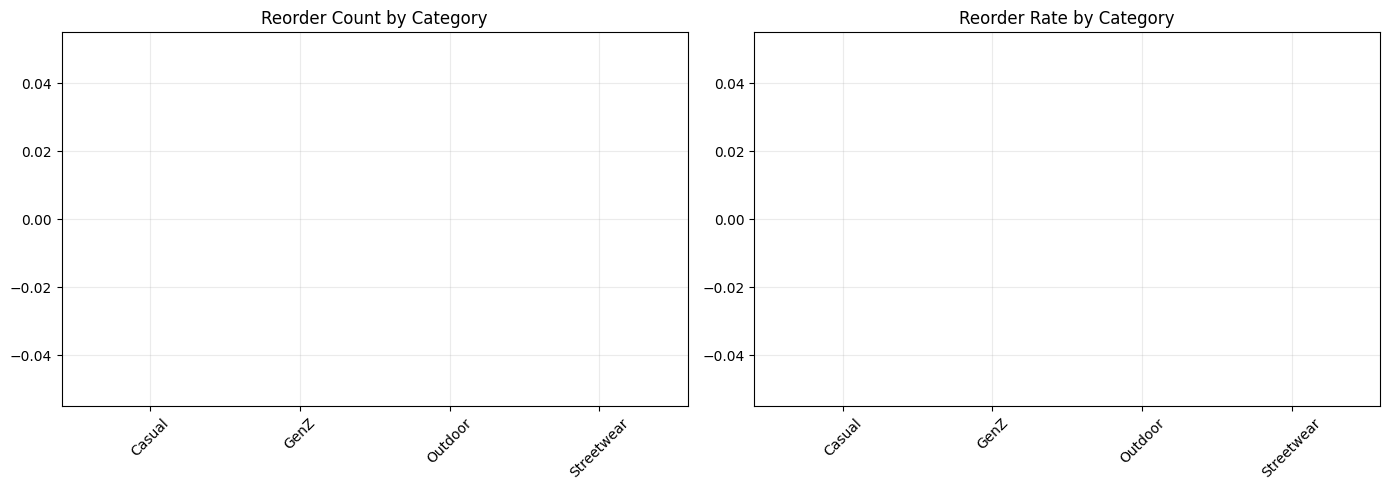

,segment_final,reorder_count,reorder_rate,average_fill_rate,average_days_of_supply
0,Activewear,0,0.0000,0.9627,"1,091.6399"
1,All-weather,0,0.0000,0.9631,494.7097
2,Balanced,0,0.0000,0.9581,837.8431
3,Everyday,0,0.0000,0.9598,"1,113.7547"
4,Performance,0,0.0000,0.9612,745.6083
5,Premium,0,0.0000,0.9616,822.4648
6,Standard,0,0.0000,0.9646,353.3401
7,Trendy,0,0.0000,0.9617,718.8122


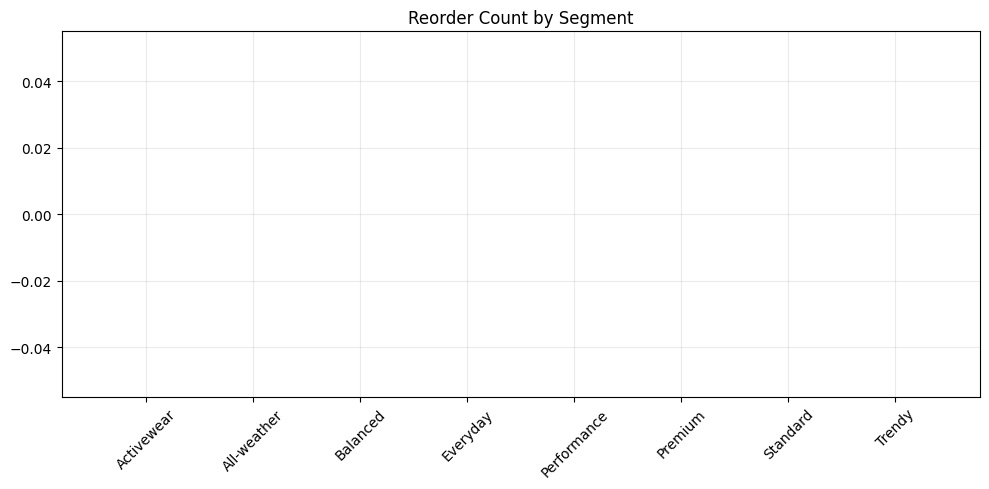

In [8]:
category_reorder = pd.DataFrame()
segment_reorder = pd.DataFrame()

if monthly_supply.empty:
    print('Monthly supply data is unavailable; category and segment reorder analysis cannot be computed.')
else:
    category_reorder = monthly_supply.groupby('category_final').agg(
        product_count=('product_id_std', 'nunique'),
        reorder_count=('reorder_flag', lambda s: int(pd.Series(s).fillna(False).sum())),
        reorder_rate=('reorder_flag', lambda s: pd.Series(s).fillna(False).mean()),
        average_reorder_quantity=('reorder_quantity', 'mean'),
        average_fill_rate=('fill_rate', 'mean'),
        average_days_of_supply=('days_of_supply', 'mean'),
    ).reset_index().sort_values(['reorder_count', 'reorder_rate'], ascending=False)
    display(category_reorder)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(category_reorder['category_final'].astype(str), category_reorder['reorder_count'], color='#E45756')
    axes[0].set_title('Reorder Count by Category')
    axes[0].tick_params(axis='x', rotation=45)
    axes[1].bar(category_reorder['category_final'].astype(str), category_reorder['reorder_rate'], color='#54A24B')
    axes[1].set_title('Reorder Rate by Category')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    if 'segment_final' in monthly_supply.columns and monthly_supply['segment_final'].dropna().any():
        segment_reorder = monthly_supply.dropna(subset=['segment_final']).groupby('segment_final').agg(
            reorder_count=('reorder_flag', lambda s: int(pd.Series(s).fillna(False).sum())),
            reorder_rate=('reorder_flag', lambda s: pd.Series(s).fillna(False).mean()),
            average_fill_rate=('fill_rate', 'mean'),
            average_days_of_supply=('days_of_supply', 'mean'),
        ).reset_index().sort_values(['reorder_count', 'reorder_rate'], ascending=False)
        display(segment_reorder)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(segment_reorder['segment_final'].astype(str), segment_reorder['reorder_count'], color='#B279A2')
        ax.set_title('Reorder Count by Segment')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print('Segment data is unavailable; segment reorder analysis is skipped.')

## 9. Monthly Reorder and Supply Trend

Aggregate reorder count, fill rate, days of supply, stock on hand, and reorder quantity by month and inspect time trends.

,year_month,reorder_count,reorder_rate,average_fill_rate,average_days_of_supply,average_stock_on_hand,reorder_quantity,month_start
0,2012-07,0,0.0000,0.9661,93.2532,59.9949,0.0000,2012-07-01
1,2012-08,0,0.0000,0.9449,99.4303,62.0544,0.0000,2012-08-01
2,2012-09,0,0.0000,0.9500,144.8526,64.9033,0.0000,2012-09-01
3,2012-10,0,0.0000,0.9526,181.2851,66.8055,0.0000,2012-10-01
4,2012-11,0,0.0000,0.9599,228.7372,73.3187,0.0000,2012-11-01
...,...,...,...,...,...,...,...,...
121,2022-08,0,0.0000,0.9652,"1,296.2913",227.5141,0.0000,2022-08-01
122,2022-09,0,0.0000,0.9670,"1,937.0587",256.1074,0.0000,2022-09-01
123,2022-10,0,0.0000,0.9618,"1,992.5443",254.9022,0.0000,2022-10-01
124,2022-11,0,0.0000,0.9599,"1,923.9303",252.6676,0.0000,2022-11-01


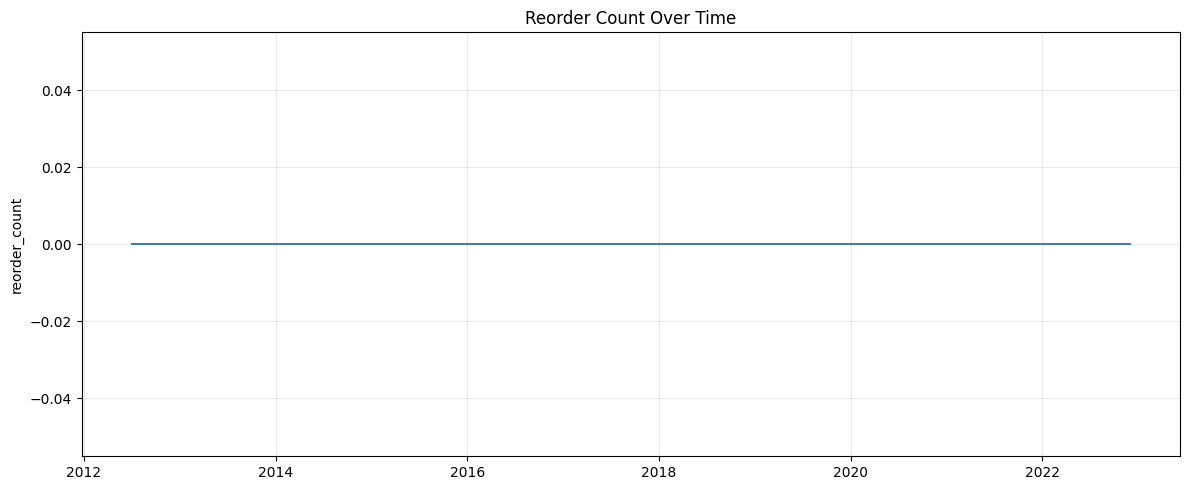

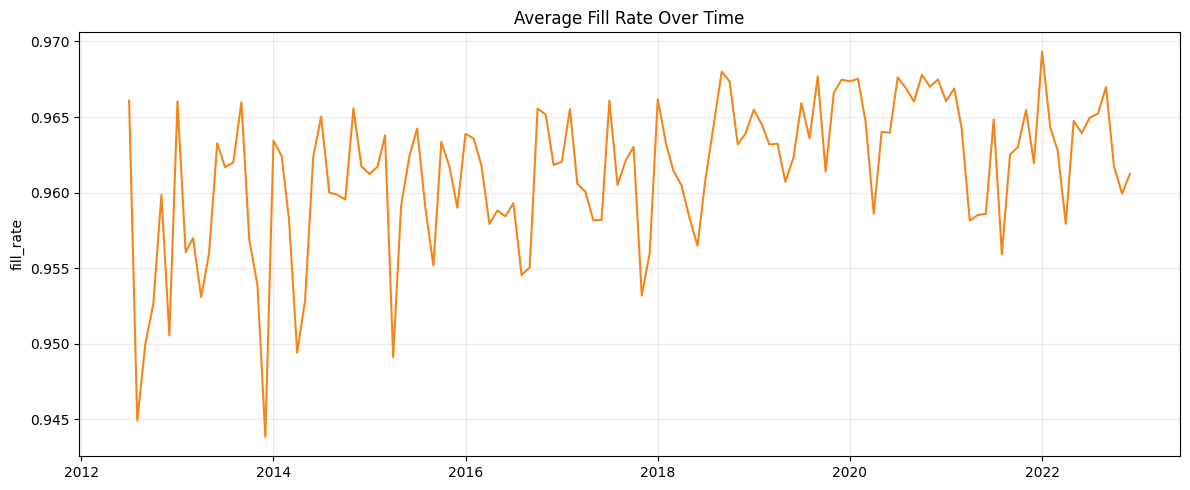

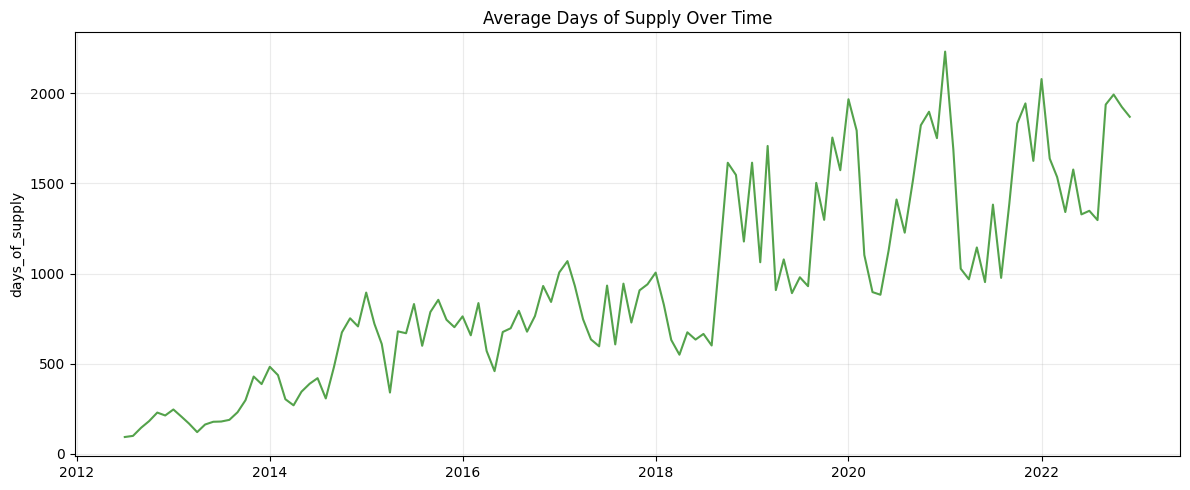

In [9]:
monthly_supply_trend = pd.DataFrame()
if monthly_supply.empty:
    print('Monthly supply data is unavailable; monthly trend analysis cannot be computed.')
else:
    monthly_supply_trend = monthly_supply.groupby('year_month').agg(
        reorder_count=('reorder_flag', lambda s: int(pd.Series(s).fillna(False).sum())),
        reorder_rate=('reorder_flag', lambda s: pd.Series(s).fillna(False).mean()),
        average_fill_rate=('fill_rate', 'mean'),
        average_days_of_supply=('days_of_supply', 'mean'),
        average_stock_on_hand=('stock_on_hand', 'mean'),
        reorder_quantity=('reorder_quantity', 'sum'),
    ).reset_index()
    monthly_supply_trend['month_start'] = pd.PeriodIndex(monthly_supply_trend['year_month'], freq='M').to_timestamp()
    display(monthly_supply_trend)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_supply_trend['month_start'], monthly_supply_trend['reorder_count'], color='#4C78A8')
    ax.set_title('Reorder Count Over Time')
    ax.set_ylabel('reorder_count')
    plt.tight_layout()
    plt.show()

    if monthly_supply_trend['average_fill_rate'].notna().any():
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(monthly_supply_trend['month_start'], monthly_supply_trend['average_fill_rate'], color='#F58518')
        ax.set_title('Average Fill Rate Over Time')
        ax.set_ylabel('fill_rate')
        plt.tight_layout()
        plt.show()

    if monthly_supply_trend['average_days_of_supply'].notna().any():
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(monthly_supply_trend['month_start'], monthly_supply_trend['average_days_of_supply'], color='#54A24B')
        ax.set_title('Average Days of Supply Over Time')
        ax.set_ylabel('days_of_supply')
        plt.tight_layout()
        plt.show()

## 10. Monthly Revenue Preparation

Aggregate Revenue by month and prepare next-month Revenue for lead-lag supply comparisons.

In [10]:
monthly_revenue = pd.DataFrame()
if sales_raw is None or sales_raw.empty or cols.get('sales_date') is None or cols.get('sales_revenue') is None:
    print('Sales data is unavailable or Revenue could not be identified; monthly Revenue preparation cannot be computed.')
else:
    sa = sales_raw.copy()
    sa['date'] = pd.to_datetime(sa[cols['sales_date']], errors='coerce').dt.floor('D')
    sa['revenue'] = to_num(sa[cols['sales_revenue']])
    sa['year_month'] = sa['date'].dt.to_period('M').astype('string')
    monthly_revenue = sa.dropna(subset=['date']).groupby('year_month', as_index=False)['revenue'].sum(min_count=1)
    monthly_revenue['month_start'] = pd.PeriodIndex(monthly_revenue['year_month'], freq='M').to_timestamp()
    monthly_revenue = monthly_revenue.sort_values('month_start')
    monthly_revenue['next_month_revenue'] = monthly_revenue['revenue'].shift(-1)
    report = pd.DataFrame([
        {'metric': 'monthly_revenue_start', 'value': monthly_revenue['month_start'].min()},
        {'metric': 'monthly_revenue_end', 'value': monthly_revenue['month_start'].max()},
        {'metric': 'monthly_revenue_months', 'value': len(monthly_revenue)},
    ])
    display(report)
    display(monthly_revenue)

,metric,value
0,monthly_revenue_start,2012-07-01 00:00:00
1,monthly_revenue_end,2022-12-01 00:00:00
2,monthly_revenue_months,126


,year_month,revenue,month_start,next_month_revenue
0,2012-07,"130,406,773.5100",2012-07-01,"159,089,240.3100"
1,2012-08,"159,089,240.3100",2012-08-01,"129,307,133.8200"
2,2012-09,"129,307,133.8200",2012-09-01,"110,185,694.4500"
3,2012-10,"110,185,694.4500",2012-10-01,"98,186,295.2400"
4,2012-11,"98,186,295.2400",2012-11-01,"114,322,610.6900"
...,...,...,...,...
121,2022-08,"113,542,943.4700",2022-08-01,"85,764,286.5900"
122,2022-09,"85,764,286.5900",2022-09-01,"75,194,452.3100"
123,2022-10,"75,194,452.3100",2022-10-01,"52,200,081.6400"
124,2022-11,"52,200,081.6400",2022-11-01,"52,454,936.2000"


## 11. Reorder Activity vs Next-Month Revenue

Compare supply metrics in month `M` with Revenue in month `M+1`. This is the leakage-safe way to inspect whether reorder pressure precedes later Revenue changes.

C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,year_month,reorder_count,reorder_rate,average_fill_rate,average_days_of_supply,average_stock_on_hand,reorder_quantity,month_start,next_month_revenue
0,2012-07,0,0.0000,0.9661,93.2532,59.9949,0.0000,2012-07-01,"159,089,240.3100"
1,2012-08,0,0.0000,0.9449,99.4303,62.0544,0.0000,2012-08-01,"129,307,133.8200"
2,2012-09,0,0.0000,0.9500,144.8526,64.9033,0.0000,2012-09-01,"110,185,694.4500"
3,2012-10,0,0.0000,0.9526,181.2851,66.8055,0.0000,2012-10-01,"98,186,295.2400"
4,2012-11,0,0.0000,0.9599,228.7372,73.3187,0.0000,2012-11-01,"114,322,610.6900"
...,...,...,...,...,...,...,...,...,...
120,2022-07,0,0.0000,0.9650,"1,347.8878",248.9829,0.0000,2022-07-01,"113,542,943.4700"
121,2022-08,0,0.0000,0.9652,"1,296.2913",227.5141,0.0000,2022-08-01,"85,764,286.5900"
122,2022-09,0,0.0000,0.9670,"1,937.0587",256.1074,0.0000,2022-09-01,"75,194,452.3100"
123,2022-10,0,0.0000,0.9618,"1,992.5443",254.9022,0.0000,2022-10-01,"52,200,081.6400"


,metric,correlation_with_next_month_revenue,valid_months
0,reorder_count,NaN,125
1,reorder_rate,NaN,125
2,average_days_of_supply,-0.5530,125
3,average_fill_rate,-0.3439,125


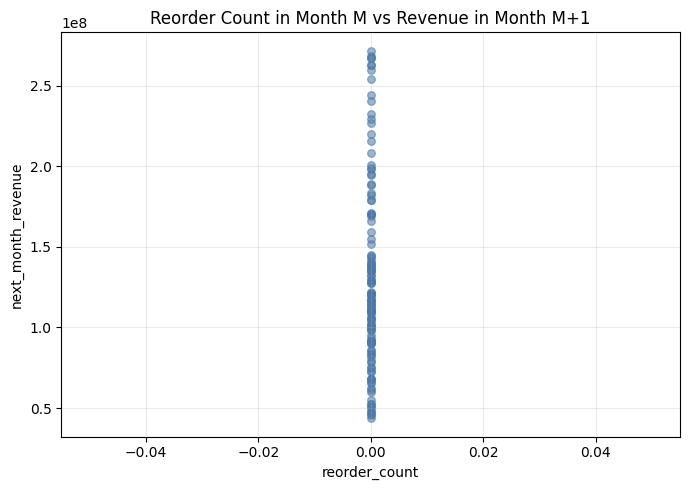

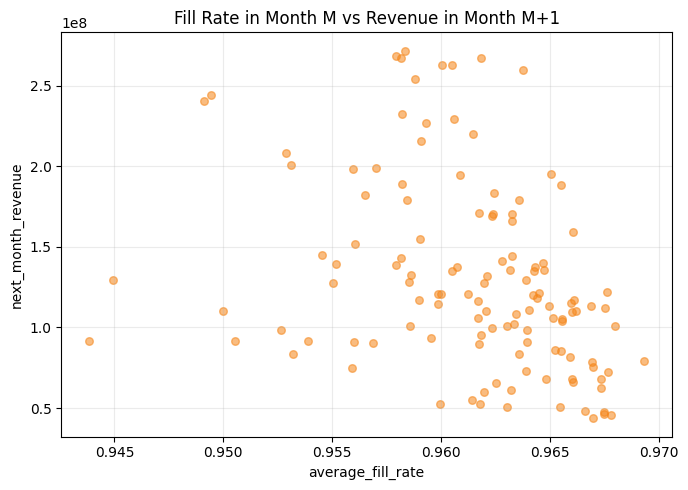

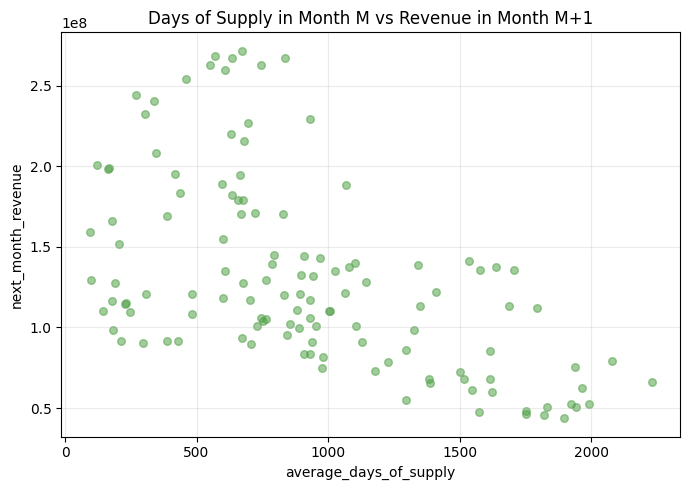

In [11]:
next_month_relation = pd.DataFrame()
relation_corr = pd.DataFrame()
if monthly_supply_trend.empty or monthly_revenue.empty:
    print('Monthly supply or Revenue data is unavailable; next-month Revenue analysis cannot be computed.')
else:
    next_month_relation = monthly_supply_trend.merge(monthly_revenue[['year_month', 'next_month_revenue']], on='year_month', how='left').dropna(subset=['next_month_revenue'])
    corr_rows = []
    for metric in ['reorder_count', 'reorder_rate', 'average_days_of_supply', 'average_fill_rate']:
        if metric in next_month_relation.columns and next_month_relation[metric].notna().sum() >= 2:
            valid = next_month_relation[[metric, 'next_month_revenue']].replace([np.inf, -np.inf], np.nan).dropna()
            corr_rows.append({'metric': metric, 'correlation_with_next_month_revenue': valid[metric].corr(valid['next_month_revenue']) if len(valid) >= 2 else np.nan, 'valid_months': len(valid)})
    relation_corr = pd.DataFrame(corr_rows)
    display(next_month_relation)
    display(relation_corr)

    fig, ax = plt.subplots(figsize=(7, 5))
    sample = next_month_relation[['reorder_count', 'next_month_revenue']].replace([np.inf, -np.inf], np.nan).dropna()
    ax.scatter(sample['reorder_count'], sample['next_month_revenue'], alpha=0.55, s=30, color='#4C78A8')
    if len(sample) >= 2 and sample['reorder_count'].nunique() > 1:
        coeff = np.polyfit(sample['reorder_count'], sample['next_month_revenue'], 1)
        x_line = np.linspace(sample['reorder_count'].min(), sample['reorder_count'].max(), 100)
        ax.plot(x_line, coeff[0] * x_line + coeff[1], color='#E45756', linewidth=2)
    ax.set_title('Reorder Count in Month M vs Revenue in Month M+1')
    ax.set_xlabel('reorder_count')
    ax.set_ylabel('next_month_revenue')
    plt.tight_layout()
    plt.show()

    if 'average_fill_rate' in next_month_relation.columns and next_month_relation['average_fill_rate'].notna().any():
        fig, ax = plt.subplots(figsize=(7, 5))
        sample = next_month_relation[['average_fill_rate', 'next_month_revenue']].replace([np.inf, -np.inf], np.nan).dropna()
        ax.scatter(sample['average_fill_rate'], sample['next_month_revenue'], alpha=0.55, s=30, color='#F58518')
        ax.set_title('Fill Rate in Month M vs Revenue in Month M+1')
        ax.set_xlabel('average_fill_rate')
        ax.set_ylabel('next_month_revenue')
        plt.tight_layout()
        plt.show()

    if 'average_days_of_supply' in next_month_relation.columns and next_month_relation['average_days_of_supply'].notna().any():
        fig, ax = plt.subplots(figsize=(7, 5))
        sample = next_month_relation[['average_days_of_supply', 'next_month_revenue']].replace([np.inf, -np.inf], np.nan).dropna()
        ax.scatter(sample['average_days_of_supply'], sample['next_month_revenue'], alpha=0.55, s=30, color='#54A24B')
        ax.set_title('Days of Supply in Month M vs Revenue in Month M+1')
        ax.set_xlabel('average_days_of_supply')
        ax.set_ylabel('next_month_revenue')
        plt.tight_layout()
        plt.show()

## 12. Fill Rate and Revenue Relationship

If fill rate is available, compare low-fill-rate months with Revenue and identify overlap with low Revenue periods.

,year_month,reorder_count,reorder_rate,average_fill_rate,average_days_of_supply,average_stock_on_hand,reorder_quantity,month_start,revenue,low_fill_flag,low_revenue_flag
0,2012-07,0,0.0000,0.9661,93.2532,59.9949,0.0000,2012-07-01,"130,406,773.5100",False,False
1,2012-08,0,0.0000,0.9449,99.4303,62.0544,0.0000,2012-08-01,"159,089,240.3100",True,False
2,2012-09,0,0.0000,0.9500,144.8526,64.9033,0.0000,2012-09-01,"129,307,133.8200",True,False
3,2012-10,0,0.0000,0.9526,181.2851,66.8055,0.0000,2012-10-01,"110,185,694.4500",True,False
4,2012-11,0,0.0000,0.9599,228.7372,73.3187,0.0000,2012-11-01,"98,186,295.2400",False,False
...,...,...,...,...,...,...,...,...,...,...,...
121,2022-08,0,0.0000,0.9652,"1,296.2913",227.5141,0.0000,2022-08-01,"113,542,943.4700",False,False
122,2022-09,0,0.0000,0.9670,"1,937.0587",256.1074,0.0000,2022-09-01,"85,764,286.5900",False,True
123,2022-10,0,0.0000,0.9618,"1,992.5443",254.9022,0.0000,2022-10-01,"75,194,452.3100",False,True
124,2022-11,0,0.0000,0.9599,"1,923.9303",252.6676,0.0000,2022-11-01,"52,200,081.6400",False,True


Low fill-rate and low Revenue overlap months:


,year_month,reorder_count,reorder_rate,average_fill_rate,average_days_of_supply,average_stock_on_hand,reorder_quantity,month_start,revenue,low_fill_flag,low_revenue_flag
16,2013-11,0,0.0000,0.9539,428.6131,110.7037,0.0000,2013-11-01,"90,371,311.8200",True,True
65,2017-12,0,0.0000,0.9560,940.0619,208.7132,0.0000,2017-12-01,"83,739,779.5700",True,True
109,2021-08,0,0.0000,0.9559,975.9119,228.2197,0.0000,2021-08-01,"68,280,026.8200",True,True


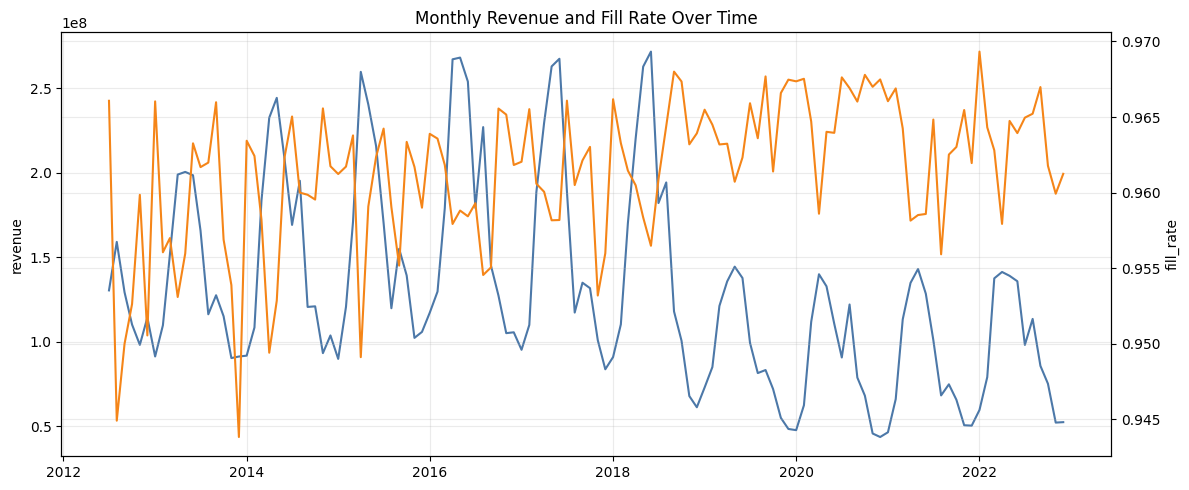

In [12]:
fill_rate_revenue = pd.DataFrame()
if monthly_supply_trend.empty or monthly_revenue.empty or monthly_supply_trend['average_fill_rate'].notna().sum() == 0:
    print('Fill rate is unavailable; fill-rate and Revenue analysis is skipped.')
else:
    fill_rate_revenue = monthly_supply_trend.merge(monthly_revenue[['year_month', 'month_start', 'revenue']], on=['year_month', 'month_start'], how='inner')
    low_fill_threshold = fill_rate_revenue['average_fill_rate'].quantile(0.25)
    low_revenue_threshold = fill_rate_revenue['revenue'].quantile(0.25)
    fill_rate_revenue['low_fill_flag'] = fill_rate_revenue['average_fill_rate'] <= low_fill_threshold
    fill_rate_revenue['low_revenue_flag'] = fill_rate_revenue['revenue'] <= low_revenue_threshold
    display(fill_rate_revenue)
    print('Low fill-rate and low Revenue overlap months:')
    display(fill_rate_revenue[fill_rate_revenue['low_fill_flag'] & fill_rate_revenue['low_revenue_flag']])

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(fill_rate_revenue['month_start'], fill_rate_revenue['revenue'], color='#4C78A8')
    ax1.set_ylabel('revenue')
    ax2 = ax1.twinx()
    ax2.plot(fill_rate_revenue['month_start'], fill_rate_revenue['average_fill_rate'], color='#F58518')
    ax2.set_ylabel('fill_rate')
    ax1.set_title('Monthly Revenue and Fill Rate Over Time')
    plt.tight_layout()
    plt.show()

## 13. Days of Supply and Revenue Relationship

If days of supply is available or was safely estimated, compare extreme low/high supply months with Revenue and reorder pressure.

In [13]:
dos_revenue = pd.DataFrame()
if monthly_supply_trend.empty or monthly_revenue.empty or monthly_supply_trend['average_days_of_supply'].notna().sum() == 0:
    print('Days of supply is unavailable; days-of-supply and Revenue analysis is skipped.')
else:
    dos_revenue = monthly_supply_trend.merge(monthly_revenue[['year_month', 'month_start', 'revenue']], on=['year_month', 'month_start'], how='inner')
    low_dos = dos_revenue['average_days_of_supply'].quantile(0.25)
    high_dos = dos_revenue['average_days_of_supply'].quantile(0.75)
    print('Months with very low days of supply:')
    display(dos_revenue[dos_revenue['average_days_of_supply'] <= low_dos].sort_values('average_days_of_supply').head(20))
    print('Months with very high days of supply:')
    display(dos_revenue[dos_revenue['average_days_of_supply'] >= high_dos].sort_values('average_days_of_supply', ascending=False).head(20))

Months with very low days of supply:


,year_month,reorder_count,reorder_rate,average_fill_rate,average_days_of_supply,average_stock_on_hand,reorder_quantity,month_start,revenue
0,2012-07,0,0.0000,0.9661,93.2532,59.9949,0.0000,2012-07-01,"130,406,773.5100"
1,2012-08,0,0.0000,0.9449,99.4303,62.0544,0.0000,2012-08-01,"159,089,240.3100"
9,2013-04,0,0.0000,0.9531,120.4514,82.1211,0.0000,2013-04-01,"198,926,932.0900"
2,2012-09,0,0.0000,0.9500,144.8526,64.9033,0.0000,2012-09-01,"129,307,133.8200"
10,2013-05,0,0.0000,0.9560,162.5620,87.5717,0.0000,2013-05-01,"200,500,109.4800"
8,2013-03,0,0.0000,0.9570,167.9905,80.8989,0.0000,2013-03-01,"151,834,657.2700"
11,2013-06,0,0.0000,0.9633,177.7736,93.4234,0.0000,2013-06-01,"198,517,628.5400"
12,2013-07,0,0.0000,0.9617,179.1254,97.1002,0.0000,2013-07-01,"165,745,353.9900"
3,2012-10,0,0.0000,0.9526,181.2851,66.8055,0.0000,2012-10-01,"110,185,694.4500"
13,2013-08,0,0.0000,0.9620,188.3795,103.3801,0.0000,2013-08-01,"116,271,755.9600"


Months with very high days of supply:


,year_month,reorder_count,reorder_rate,average_fill_rate,average_days_of_supply,average_stock_on_hand,reorder_quantity,month_start,revenue
102,2021-01,0,0.0000,0.9660,"2,230.7883",279.2573,0.0000,2021-01-01,"46,473,094.4200"
114,2022-01,0,0.0000,0.9693,"2,078.4840",258.5876,0.0000,2022-01-01,"59,663,486.3200"
123,2022-10,0,0.0000,0.9618,"1,992.5443",254.9022,0.0000,2022-10-01,"75,194,452.3100"
90,2020-01,0,0.0000,0.9674,"1,966.6658",273.9112,0.0000,2020-01-01,"47,728,257.0000"
112,2021-11,0,0.0000,0.9655,"1,943.3905",263.8175,0.0000,2021-11-01,"50,638,497.4600"
122,2022-09,0,0.0000,0.9670,"1,937.0587",256.1074,0.0000,2022-09-01,"85,764,286.5900"
124,2022-11,0,0.0000,0.9599,"1,923.9303",252.6676,0.0000,2022-11-01,"52,200,081.6400"
100,2020-11,0,0.0000,0.9670,"1,897.2649",275.1194,0.0000,2020-11-01,"45,740,881.4500"
125,2022-12,0,0.0000,0.9612,"1,869.2295",245.8373,0.0000,2022-12-01,"52,454,936.2000"
111,2021-10,0,0.0000,0.9630,"1,832.2770",243.5163,0.0000,2021-10-01,"65,692,136.1600"


## 14. Leakage-Safe Supply-Planning Forecast Feature Preview

Shift month-level supply metrics by one month before using them as forecast features. Month `M` supply metrics are used to forecast month `M+1` or later, not the same realized month.

In [14]:
feature_preview = pd.DataFrame()
feature_registry = pd.DataFrame()

if monthly_supply_trend.empty:
    print('Monthly supply metrics are unavailable; feature preview cannot be built.')
else:
    features = monthly_supply_trend.sort_values('month_start').copy()
    features['reorder_count_lag'] = features['reorder_count'].shift(1)
    features['reorder_rate_lag'] = features['reorder_rate'].shift(1)
    features['reorder_quantity_lag'] = features['reorder_quantity'].shift(1)
    features['avg_days_of_supply_lag'] = features['average_days_of_supply'].shift(1)
    features['fill_rate_lag'] = features['average_fill_rate'].shift(1)
    features['avg_stock_on_hand_lag'] = features['average_stock_on_hand'].shift(1)
    features['reorder_count_roll_mean_3m'] = features['reorder_count'].shift(1).rolling(3, min_periods=2).mean()
    features['fill_rate_roll_mean_3m'] = features['average_fill_rate'].shift(1).rolling(3, min_periods=2).mean()
    features['days_of_supply_roll_mean_3m'] = features['average_days_of_supply'].shift(1).rolling(3, min_periods=2).mean()
    if not monthly_supply.empty:
        cat_pressure = monthly_supply.groupby(['year_month', 'category_final'])['reorder_flag'].mean().reset_index(name='category_reorder_rate')
        top_cat_pressure = cat_pressure.groupby('year_month')['category_reorder_rate'].max().reset_index(name='category_reorder_pressure')
        features = features.merge(top_cat_pressure, on='year_month', how='left')
        features['category_reorder_pressure_lag'] = features['category_reorder_pressure'].shift(1)
    if not monthly_revenue.empty:
        feature_preview = monthly_revenue[['year_month', 'month_start', 'revenue']].merge(features, on=['year_month', 'month_start'], how='left')
    else:
        feature_preview = features.copy()
    display(feature_preview[['month_start', 'revenue', 'reorder_count_lag', 'reorder_rate_lag', 'reorder_quantity_lag', 'avg_days_of_supply_lag', 'fill_rate_lag', 'avg_stock_on_hand_lag', 'reorder_count_roll_mean_3m', 'fill_rate_roll_mean_3m', 'days_of_supply_roll_mean_3m'] + ([c for c in ['category_reorder_pressure_lag'] if c in feature_preview.columns])].head(24))

    current_known_only = ['reorder_count', 'reorder_rate', 'reorder_quantity', 'average_days_of_supply', 'average_fill_rate', 'average_stock_on_hand']
    historical_safe = [c for c in feature_preview.columns if c.endswith('_lag') or c.endswith('_3m')]
    feature_registry = pd.DataFrame({
        'feature': current_known_only + historical_safe,
        'feature_type': ['requires known current/future supply plan'] * len(current_known_only) + ['historical lagged monthly only'] * len(historical_safe),
        'forecast_use_note': ['Use only if the supply-planning value is genuinely known before prediction.'] * len(current_known_only) + ['Leakage-safe because the supply metric is shifted to prior month history.'] * len(historical_safe),
    })
    display(feature_registry)

,month_start,revenue,reorder_count_lag,reorder_rate_lag,reorder_quantity_lag,avg_days_of_supply_lag,fill_rate_lag,avg_stock_on_hand_lag,reorder_count_roll_mean_3m,fill_rate_roll_mean_3m,days_of_supply_roll_mean_3m,category_reorder_pressure_lag
0,2012-07-01,"130,406,773.5100",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-08-01,"159,089,240.3100",0.0000,0.0000,0.0000,93.2532,0.9661,59.9949,NaN,NaN,NaN,0.0000
2,2012-09-01,"129,307,133.8200",0.0000,0.0000,0.0000,99.4303,0.9449,62.0544,0.0000,0.9555,96.3417,0.0000
3,2012-10-01,"110,185,694.4500",0.0000,0.0000,0.0000,144.8526,0.9500,64.9033,0.0000,0.9537,112.5120,0.0000
4,2012-11-01,"98,186,295.2400",0.0000,0.0000,0.0000,181.2851,0.9526,66.8055,0.0000,0.9492,141.8560,0.0000
5,2012-12-01,"114,322,610.6900",0.0000,0.0000,0.0000,228.7372,0.9599,73.3187,0.0000,0.9542,184.9583,0.0000
6,2013-01-01,"91,308,677.0300",0.0000,0.0000,0.0000,212.7223,0.9506,73.1024,0.0000,0.9543,207.5815,0.0000
7,2013-02-01,"109,783,137.9400",0.0000,0.0000,0.0000,245.8856,0.9660,79.3026,0.0000,0.9588,229.1150,0.0000
8,2013-03-01,"151,834,657.2700",0.0000,0.0000,0.0000,205.5153,0.9561,79.1332,0.0000,0.9575,221.3744,0.0000
9,2013-04-01,"198,926,932.0900",0.0000,0.0000,0.0000,167.9905,0.9570,80.8989,0.0000,0.9597,206.4638,0.0000


,feature,feature_type,forecast_use_note
0,reorder_count,requires known current/future supply plan,Use only if the supply-planning value is genui...
1,reorder_rate,requires known current/future supply plan,Use only if the supply-planning value is genui...
2,reorder_quantity,requires known current/future supply plan,Use only if the supply-planning value is genui...
3,average_days_of_supply,requires known current/future supply plan,Use only if the supply-planning value is genui...
4,average_fill_rate,requires known current/future supply plan,Use only if the supply-planning value is genui...
5,average_stock_on_hand,requires known current/future supply plan,Use only if the supply-planning value is genui...
6,reorder_count_lag,historical lagged monthly only,Leakage-safe because the supply metric is shif...
7,reorder_rate_lag,historical lagged monthly only,Leakage-safe because the supply metric is shif...
8,reorder_quantity_lag,historical lagged monthly only,Leakage-safe because the supply metric is shif...
9,avg_days_of_supply_lag,historical lagged monthly only,Leakage-safe because the supply metric is shif...


## 15. Key Observations and Warnings

Final concise summary with reorder concentration, next-month Revenue relationship, fill-rate and days-of-supply notes, data quality warnings, and leakage-safe features.

In [15]:
def fmt(x, digits=4):
    return 'n/a' if pd.isna(x) else f'{x:,.{digits}f}'

summary_lines = []

if not product_reorder.empty:
    top_products = product_reorder.head(8)
    summary_lines.append('Products with the highest reorder frequency: ' + ', '.join(f"{r.product_id_std} ({int(r.reorder_count)}/{int(r.total_periods_observed)})" for r in top_products.itertuples()))
else:
    summary_lines.append('Product reorder frequency could not be summarized because monthly supply data was unavailable.')

if not category_reorder.empty:
    top_categories = category_reorder.head(5)
    summary_lines.append('Categories with the strongest reorder pressure: ' + ', '.join(f"{r.category_final} ({int(r.reorder_count)}, rate {r.reorder_rate:.2%})" for r in top_categories.itertuples()))
if not segment_reorder.empty:
    top_segments = segment_reorder.head(5)
    summary_lines.append('Segments with the strongest reorder pressure: ' + ', '.join(f"{r.segment_final} ({int(r.reorder_count)}, rate {r.reorder_rate:.2%})" for r in top_segments.itertuples()))

if not monthly_supply_trend.empty:
    top_months = monthly_supply_trend.sort_values('reorder_count', ascending=False).head(5)
    summary_lines.append('Months with the highest reorder activity: ' + ', '.join(f"{r.year_month} ({int(r.reorder_count)})" for r in top_months.itertuples()))

valid_relation_corr = relation_corr.dropna(subset=['correlation_with_next_month_revenue']) if not relation_corr.empty else pd.DataFrame()
if not valid_relation_corr.empty:
    best = valid_relation_corr.iloc[valid_relation_corr['correlation_with_next_month_revenue'].abs().argmax()]
    strength = 'strong' if abs(best['correlation_with_next_month_revenue']) >= 0.5 else ('weak' if abs(best['correlation_with_next_month_revenue']) < 0.2 else 'unclear')
    summary_lines.append(f"Reorder activity vs next-month Revenue appears {strength}; strongest simple relationship is {best['metric']} at {fmt(best['correlation_with_next_month_revenue'], 4)}.")
else:
    summary_lines.append('Reorder activity vs next-month Revenue relationship is unclear under the available correlation checks.')

if not fill_rate_revenue.empty:
    overlap = int((fill_rate_revenue['low_fill_flag'] & fill_rate_revenue['low_revenue_flag']).sum())
    summary_lines.append(f'Low fill rate aligns with low Revenue in {overlap} flagged months under the current threshold rules.')
else:
    summary_lines.append('Fill-rate and Revenue alignment could not be evaluated because fill rate was unavailable.')

if not dos_revenue.empty:
    corr = dos_revenue[['average_days_of_supply', 'revenue']].dropna().corr().iloc[0, 1] if len(dos_revenue[['average_days_of_supply', 'revenue']].dropna()) >= 2 else np.nan
    summary_lines.append(f'Days of supply appears usable as a descriptive supply signal; correlation with same-month Revenue is {fmt(corr, 4)}.')
else:
    summary_lines.append('Days-of-supply analysis could not be fully evaluated because direct or estimated days_of_supply was unavailable.')

all_warnings = []
all_warnings.extend(inventory_warnings)
all_warnings.extend(sales_qty_warnings)
if all_warnings:
    summary_lines.append('Data quality warnings related to reorder, fill rate, inventory, and Revenue: ' + '; '.join(all_warnings))
else:
    summary_lines.append('Data quality warnings related to reorder, fill rate, inventory, and Revenue: none beyond the checks reported in the notebook tables.')

summary_lines.append('Recommended leakage-safe supply-planning forecast features: reorder_count_lag, reorder_rate_lag, reorder_quantity_lag, avg_days_of_supply_lag, fill_rate_lag, avg_stock_on_hand_lag, reorder_count_roll_mean_3m, fill_rate_roll_mean_3m, days_of_supply_roll_mean_3m, and category_reorder_pressure_lag.')
summary_lines.append('Future reorder, fill-rate, and days-of-supply values must not be used directly unless they are genuinely known before prediction.')
summary_lines.append('Causal caution: this is observational EDA. Reorder pressure, fill rate, and Revenue can move together because of demand shifts, replenishment timing, promotions, and stock constraints.')

print('KEY OBSERVATIONS AND WARNINGS')
for line in summary_lines:
    print('-', line)

KEY OBSERVATIONS AND WARNINGS
- Products with the highest reorder frequency: 1 (0/3), 10 (0/8), 100 (0/10), 1000 (0/124), 1001 (0/115), 1002 (0/44), 1003 (0/15), 1005 (0/95)
- Categories with the strongest reorder pressure: Casual (0, rate 0.00%), GenZ (0, rate 0.00%), Outdoor (0, rate 0.00%), Streetwear (0, rate 0.00%)
- Segments with the strongest reorder pressure: Activewear (0, rate 0.00%), All-weather (0, rate 0.00%), Balanced (0, rate 0.00%), Everyday (0, rate 0.00%), Performance (0, rate 0.00%)
- Months with the highest reorder activity: 2012-07 (0), 2012-08 (0), 2012-09 (0), 2012-10 (0), 2012-11 (0)
- Reorder activity vs next-month Revenue appears strong; strongest simple relationship is average_days_of_supply at -0.5530.
- Low fill rate aligns with low Revenue in 3 flagged months under the current threshold rules.
- Days of supply appears usable as a descriptive supply signal; correlation with same-month Revenue is -0.5965.
- Data quality warnings related to reorder, fill rate